# Homework 3 - Part 1



**Name:** Gavin Amuok 
**EID:** goa266

# Linear Algebra, Computational Iterative Methods

## First Up, Jacobi.

In [34]:
import numpy as np
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy() 
    
    tolArray = []
    
    for k in range(max_iterations):
        x_new = np.zeros_like(x) 
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]        
        # Check for convergence
        currentTol = np.linalg.norm(x_new - x, ord=np.inf)
        tolArray.append(currentTol)
        if currentTol < tol:
            return x_new, k, tolArray
        x = x_new
    return x, max_iterations, tolArray


## Next up is Gauss-Seidel
### Look at the difference in algorithms.

In [35]:
import numpy as np
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()

    tolArray = []
    
    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))  # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))  # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        
        # Check for convergence
        currentTol = np.linalg.norm(x_new - x, ord=np.inf)
        tolArray.append(currentTol)
        
        if currentTol < tol:
            return x_new, k, tolArray
        
        x = x_new
    
    return x, max_iterations, tolArray



### System A

```python
A_A = np.array([
    [ 4, -1,  0,  0,  0,  0,  0,  0,  0,  0],
    [-1,  4, -1,  0,  0,  0,  0,  0,  0,  0],
    [ 0, -1,  4, -1,  0,  0,  0,  0,  0,  0],
    [ 0,  0, -1,  4, -1,  0,  0,  0,  0,  0],
    [ 0,  0,  0, -1,  4, -1,  0,  0,  0,  0],
    [ 0,  0,  0,  0, -1,  4, -1,  0,  0,  0],
    [ 0,  0,  0,  0,  0, -1,  4, -1,  0,  0],
    [ 0,  0,  0,  0,  0,  0, -1,  4, -1,  0],
    [ 0,  0,  0,  0,  0,  0,  0, -1,  4, -1],
    [ 0,  0,  0,  0,  0,  0,  0,  0, -1,  4]
], dtype=float)
b_A = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 31], dtype=float)
```

### System B

```python
A_B = np.array([
    [ 2, -1,  0,  0,  0,  0,  0,  0,  0,  0],
    [-1,  2, -1,  0,  0,  0,  0,  0,  0,  0],
    [ 0, -1,  2, -1,  0,  0,  0,  0,  0,  0],
    [ 0,  0, -1,  2, -1,  0,  0,  0,  0,  0],
    [ 0,  0,  0, -1,  2, -1,  0,  0,  0,  0],
    [ 0,  0,  0,  0, -1,  2, -1,  0,  0,  0],
    [ 0,  0,  0,  0,  0, -1,  2, -1,  0,  0],
    [ 0,  0,  0,  0,  0,  0, -1,  2, -1,  0],
    [ 0,  0,  0,  0,  0,  0,  0, -1,  2, -1],
    [ 0,  0,  0,  0,  0,  0,  0,  0, -1,  2]
], dtype=float)
b_B = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 11], dtype=float)

In [36]:
## Code here - System A, Jacobi
def jacobiA():
    A_A = np.array([
        [ 4, -1,  0,  0,  0,  0,  0,  0,  0,  0],
        [-1,  4, -1,  0,  0,  0,  0,  0,  0,  0],
        [ 0, -1,  4, -1,  0,  0,  0,  0,  0,  0],
        [ 0,  0, -1,  4, -1,  0,  0,  0,  0,  0],
        [ 0,  0,  0, -1,  4, -1,  0,  0,  0,  0],
        [ 0,  0,  0,  0, -1,  4, -1,  0,  0,  0],
        [ 0,  0,  0,  0,  0, -1,  4, -1,  0,  0],
        [ 0,  0,  0,  0,  0,  0, -1,  4, -1,  0],
        [ 0,  0,  0,  0,  0,  0,  0, -1,  4, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1,  4]
    ], dtype=float)
    b_A = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 31], dtype=float)
    x0 = np.zeros_like(b_A)
    tol = 1e-6
    max_iterations = 100
    solution, iterations, tolArray = jacobi(A_A, b_A, x0, tol, max_iterations)

    print('\tJacobi System A')
    print(f"Solution: {solution}")
    print(f"Iterations: {iterations}\n")
    return tolArray
#jacobiA()

In [37]:
## Code here - System A, Guass-Seidel
def gausSidA():
    A_A = np.array([
        [ 4, -1,  0,  0,  0,  0,  0,  0,  0,  0],
        [-1,  4, -1,  0,  0,  0,  0,  0,  0,  0],
        [ 0, -1,  4, -1,  0,  0,  0,  0,  0,  0],
        [ 0,  0, -1,  4, -1,  0,  0,  0,  0,  0],
        [ 0,  0,  0, -1,  4, -1,  0,  0,  0,  0],
        [ 0,  0,  0,  0, -1,  4, -1,  0,  0,  0],
        [ 0,  0,  0,  0,  0, -1,  4, -1,  0,  0],
        [ 0,  0,  0,  0,  0,  0, -1,  4, -1,  0],
        [ 0,  0,  0,  0,  0,  0,  0, -1,  4, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1,  4]
    ], dtype=float)
    b_A = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 31], dtype=float)
    x0 = np.zeros_like(b_A)
    tol = 1e-6
    max_iterations = 100
    solution, iterations, tolArray = gauss_seidel(A_A, b_A, x0, tol, max_iterations)

    print('\tGauss-Seidel System A')
    print(f"Solution: {solution}")
    print(f"Iterations: {iterations}\n")
    return tolArray
#gausSidA()

In [38]:
## Code here - System B, Jacobi
def jacobiB():
    A_B = np.array([
        [ 2, -1,  0,  0,  0,  0,  0,  0,  0,  0],
        [-1,  2, -1,  0,  0,  0,  0,  0,  0,  0],
        [ 0, -1,  2, -1,  0,  0,  0,  0,  0,  0],
        [ 0,  0, -1,  2, -1,  0,  0,  0,  0,  0],
        [ 0,  0,  0, -1,  2, -1,  0,  0,  0,  0],
        [ 0,  0,  0,  0, -1,  2, -1,  0,  0,  0],
        [ 0,  0,  0,  0,  0, -1,  2, -1,  0,  0],
        [ 0,  0,  0,  0,  0,  0, -1,  2, -1,  0],
        [ 0,  0,  0,  0,  0,  0,  0, -1,  2, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1,  2]
    ], dtype=float)
    b_B = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 11], dtype=float)
    x0 = np.zeros_like(b_B)
    tol = 1e-6
    max_iterations = 100
    solution, iterations, tolArray = jacobi(A_B, b_B, x0, tol, max_iterations)

    print('\tJacobi System B')
    print(f"Solution: {solution}")
    print(f"Iterations: {iterations}\n")
    return tolArray
#jacobiB()

In [39]:
## Code here - System B, Gauss-Seidel
def gausSidB():
    A_B = np.array([
        [ 2, -1,  0,  0,  0,  0,  0,  0,  0,  0],
        [-1,  2, -1,  0,  0,  0,  0,  0,  0,  0],
        [ 0, -1,  2, -1,  0,  0,  0,  0,  0,  0],
        [ 0,  0, -1,  2, -1,  0,  0,  0,  0,  0],
        [ 0,  0,  0, -1,  2, -1,  0,  0,  0,  0],
        [ 0,  0,  0,  0, -1,  2, -1,  0,  0,  0],
        [ 0,  0,  0,  0,  0, -1,  2, -1,  0,  0],
        [ 0,  0,  0,  0,  0,  0, -1,  2, -1,  0],
        [ 0,  0,  0,  0,  0,  0,  0, -1,  2, -1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, -1,  2]
    ], dtype=float)
    b_B = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 11], dtype=float)
    x0 = np.zeros_like(b_B)
    tol = 1e-6
    max_iterations = 100
    solution, iterations, tolArray = gauss_seidel(A_B, b_B, x0, tol, max_iterations)

    print('\tGauss-Seidel System B')
    print(f"Solution: {solution}")
    print(f"Iterations: {iterations}\n")
    return tolArray
#gausSidB()

In [40]:
## Code here - Plot Jacobi A
import matplotlib.pyplot as plt
def plotJacobiA():
    y = jacobiA()

    start = 0
    end = len(y)
    step = 1
    
    x = np.arange(start,end,step)
    
    plt.figure()
    dotSize = 7
    plt.scatter(x,y, s=dotSize)

    plt.xlabel('# of iterations')
    plt.ylabel('error')
    plt.title('Jacobi A Plot')
#plotJacobiA()

In [41]:
## Code here - Plot Jacobi B
import matplotlib.pyplot as plt
def plotJacobiB():
    y = jacobiB()

    start = 0
    end = len(y)
    step = 1
    
    x = np.arange(start,end,step)
    
    plt.figure()
    dotSize = 7
    plt.scatter(x,y, s=dotSize)

    plt.xlabel('# of iterations')
    plt.ylabel('error')
    plt.title('Jacobi B Plot')
#plotJacobiB()

In [42]:
## Code here - Plot Gauss-Seidel A
import matplotlib.pyplot as plt
def plotGausSidA():
    y = gausSidA()
    
    start = 0
    end = len(y)
    step = 1
    
    x = np.arange(start,end,step)
    
    plt.figure()
    dotSize = 7
    plt.scatter(x,y, s=dotSize)

    plt.xlabel('# of iterations')
    plt.ylabel('error')
    plt.title('Gauss-Seid A Plot')
#plotGausSidA()

In [43]:
## Code here - Plot Gauss-Seidel B
import matplotlib.pyplot as plt
def plotGausSidB():
    y = gausSidB()

    start = 0
    end = len(y)
    step = 1
    
    x = np.arange(start,end,step)
    
    plt.figure()
    dotSize = 7
    plt.scatter(x,y, s=dotSize)

    plt.xlabel('# of iterations')
    plt.ylabel('error')
    plt.title('Gauss-Seid B Plot')
#plotGausSidB()

	Jacobi System A
Solution: [0.99999982 1.99999965 2.99999952 3.99999939 4.99999936 5.99999932
 6.99999939 7.99999947 8.99999963 9.9999998 ]
Iterations: 21

	Gauss-Seidel System A
Solution: [ 0.9999999   1.9999999   2.99999993  3.99999996  4.99999998  5.99999999
  6.99999999  8.          9.         10.        ]
Iterations: 14

	Jacobi System B
Solution: [0.96929204 1.93858409 2.91762564 3.8966672  4.89211244 5.88755768
 6.90085275 7.91414782 8.94107167 9.96799552]
Iterations: 100

	Gauss-Seidel System B
Solution: [0.99925696 1.99863187 2.99816499 3.99788082 4.99778741 5.99787704
 6.99812806 7.99850773 8.99897572 9.99948786]
Iterations: 100



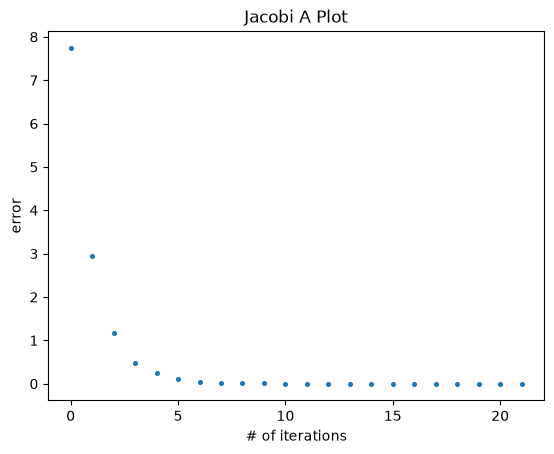

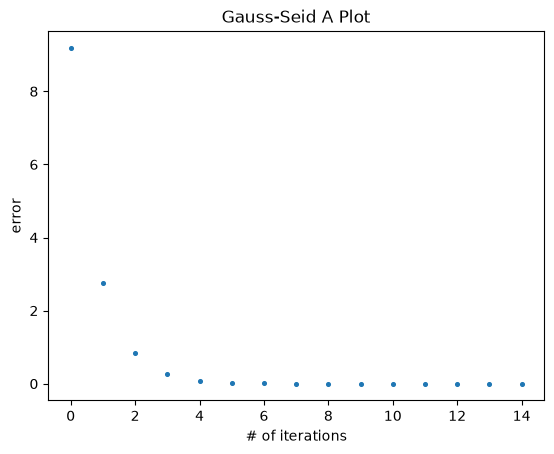

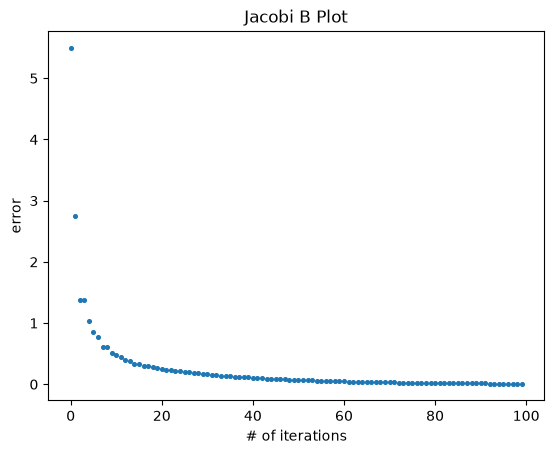

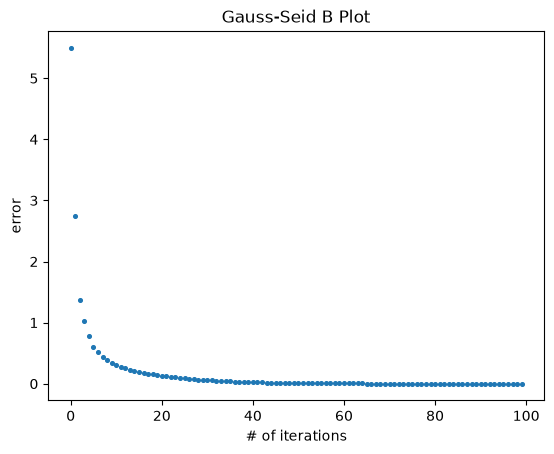

In [44]:
plotJacobiA()
plotGausSidA()
plotJacobiB()
plotGausSidB()

You should be seeing a difference in convergence rate, what's causing the difference? (We're not looking for an essay, just a few sentences describing what you see and what you think is causing the slower convergence rate)

The Gauss-Seidel method converges faster than the Jacobi method. I think it does so because the Jacobi method will find values at an iteration then based off those find the next solution set, whereas the Gauss-Seidel method will estimate a single part of the solution then use that updated value within the same iteration for finding the rest of the soultion rather than waiting to use the estimate in the next iteration. In my head its like the Jacobi method is climbing multiple stairs at once but you have to push really hard from the last one, and the Gauss-Seidel is like sprinting up the stairs one at a time allowing you to be more efficent.